In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
from scipy import stats

from src.processing import criando_cenarios_amostragem, amostrar_por_regiao
from src.statistics import comparar_distribuicoes, gerar_amostras_mcmc_por_problema
from src.visualization import plota_comparacao_distribuicoes

# 1. Distribuicoes empiricas de erro

- Sampling para gerar conjunto de validacao do erro empirico (só 3% uniforme mesmo)
- Captura distribuicoes e estatisticas (media e desvpad) de erro
    - Por regiao/problema
- Kolmogorov Smirnoff para comparar com distribuicao do erro usando (100%) da base como validacao vs. 3%
- Super analise com print, resultado/valor do KS, histogramas sobrepostos das 2 distribuicoes, estatisticas do erro na base 3% e na base 100%, WAPE

In [2]:
df_surrogate1 = pd.read_parquet('data/df_surrogate1.parquet')
df_surrogate2 = pd.read_parquet('data/df_surrogate2.parquet')

### I. Amostragem

In [3]:
# define parametros para criacao de cenários de amostragem
taxa_amostragem_global = 0.03 #1/10 do conjunto de treino
n_regioes = 5
proporcionalidade = 15

# definindo cenários de amostragem
df_amostragem1 = criando_cenarios_amostragem(df_surrogate1, 
                                taxa_amostragem_global,
                                n_regioes,
                                proporcionalidade)

df_amostragem2 = criando_cenarios_amostragem(df_surrogate2, 
                                taxa_amostragem_global,
                                n_regioes,
                                proporcionalidade)

# realizando amostragem por cenário
df_validacao1 = amostrar_por_regiao(df_surrogate1, df_amostragem1, 'cenario1')
df_validacao2 = amostrar_por_regiao(df_surrogate2, df_amostragem2, 'cenario1')


# tamanho das amostras
#display(df_validacao1.groupby('regiao').size().reset_index(name='count'))
display(df_validacao2.groupby('regiao').size().reset_index(name='count'))
display(df_surrogate1.groupby('regiao').size().reset_index(name='count'))
#display(df_surrogate2.groupby('regiao').size().reset_index(name='count'))

taxa % amostragem média


cenario1    0.030000
cenario2    0.032390
cenario3    0.035087
dtype: float64

taxa % amostragem média


cenario1    0.030000
cenario2    0.032774
cenario3    0.033949
dtype: float64

,regiao,count
0,1,6000
1,2,6000
2,3,6000
3,4,6000
4,5,6000


,regiao,count
0,1,200000
1,2,200000
2,3,200000
3,4,200000
4,5,200000


### II. Kolmogorov-Smirnov

In [4]:
# Problema 1
df_dist1_f1 = comparar_distribuicoes(df_surrogate1, df_validacao1, col='erro1_c1', problema='problema1')
df_dist1_f2 = comparar_distribuicoes(df_surrogate1, df_validacao1, col='erro2_c1', problema='problema1')

# Problema 2
df_dist2_f1 = comparar_distribuicoes(df_surrogate2, df_validacao2, col='erro1_c1', problema='problema2')
df_dist2_f2 = comparar_distribuicoes(df_surrogate2, df_validacao2, col='erro2_c1', problema='problema2')

# Combinar todos os resultados
df_todos_resultados = pd.concat([df_dist1_f1, df_dist1_f2, df_dist2_f1, df_dist2_f2], ignore_index=True)

display(df_todos_resultados.head())

,problema,objetivo,regiao,coluna,ks_statistic,ks_pvalue,distribuicoes_iguais,media_geral,media_validacao,desvpad_geral,desvpad_validacao,size_geral,size_validacao,wape_geral,wape_validacao
0,problema1,fitness1,1,erro1_c1,0.010447,0.544988,Sim,0.007009,-0.000114,0.882594,0.878787,200000,6000,0.247097,0.245979
1,problema1,fitness1,2,erro1_c1,0.008615,0.776870,Sim,-0.000405,0.004266,0.438991,0.433653,200000,6000,0.093263,0.091810
2,problema1,fitness1,3,erro1_c1,0.010447,0.544988,Sim,-0.001893,-0.000073,0.263930,0.262829,200000,6000,0.082887,0.082463
3,problema1,fitness1,4,erro1_c1,0.008178,0.827590,Sim,0.008074,0.002589,1.096437,1.093807,200000,6000,0.352747,0.350335
4,problema1,fitness1,5,erro1_c1,0.012530,0.317175,Sim,-0.012883,0.000705,1.756147,1.742756,200000,6000,0.460397,0.452938


Plotando comparações de distribuições - Problema 1...


/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/src/visualization.py:1204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.99], pad=0.5)
/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


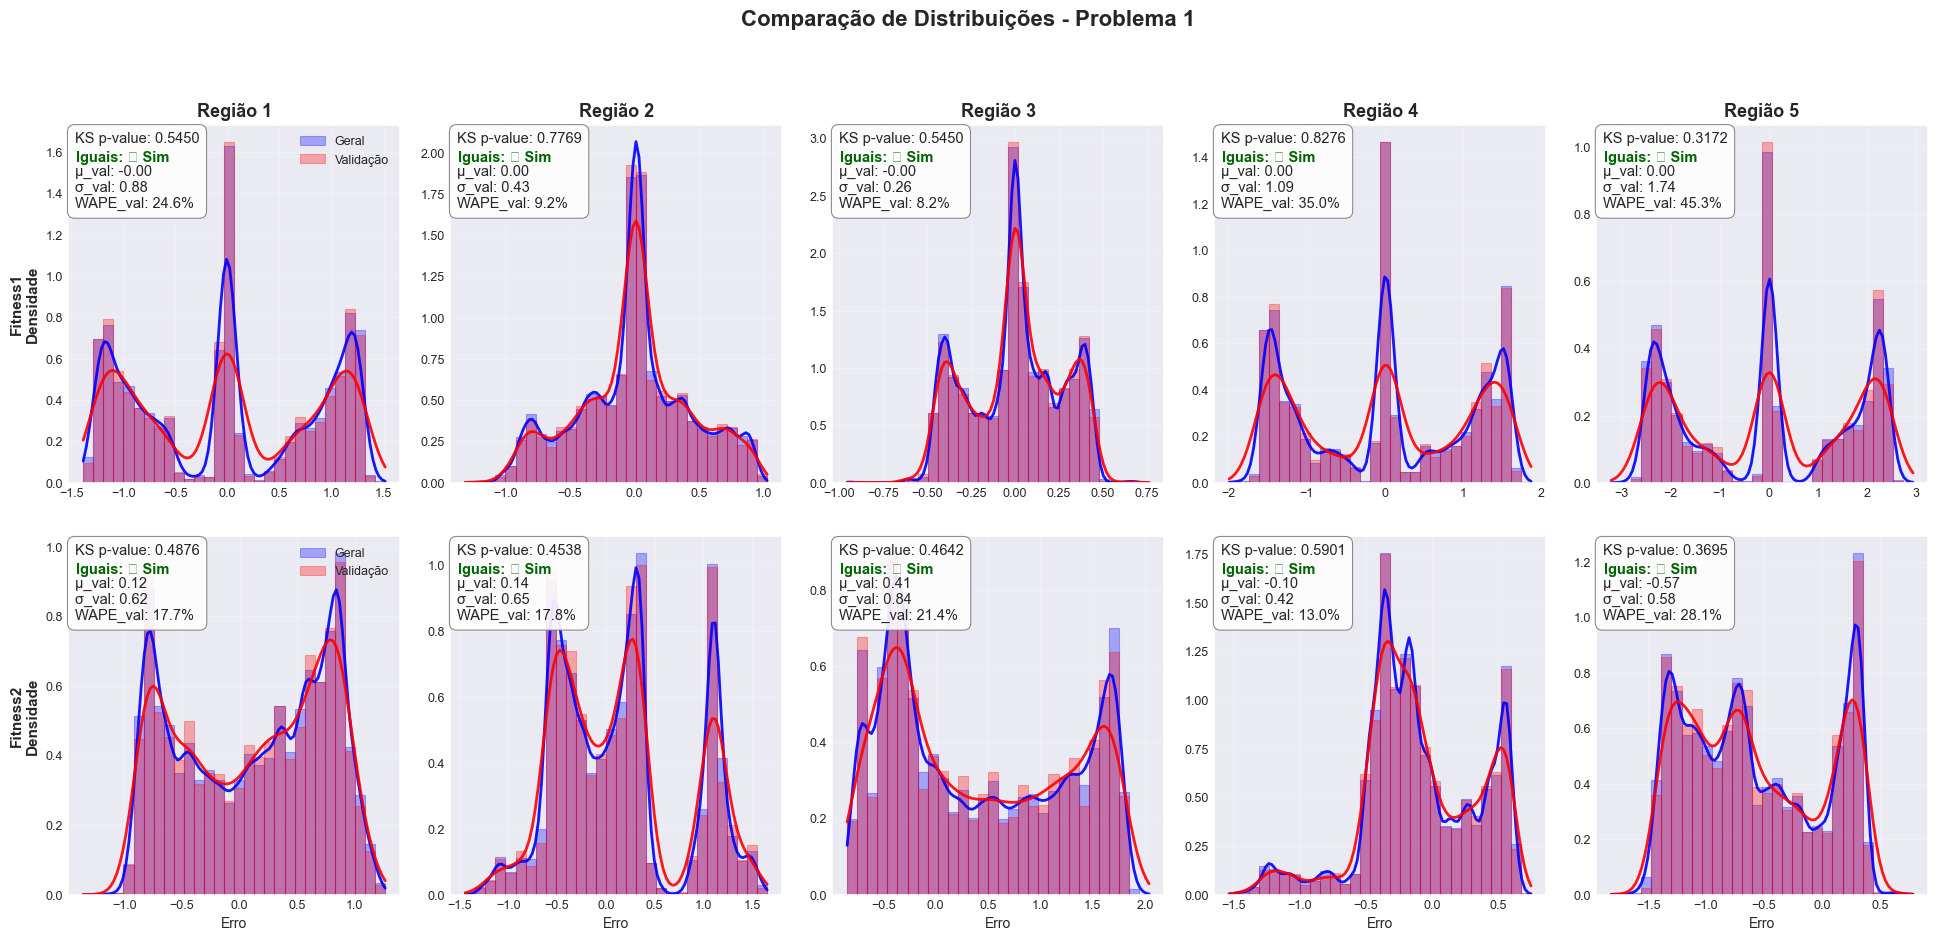

Plotando comparações de distribuições - Problema 2...


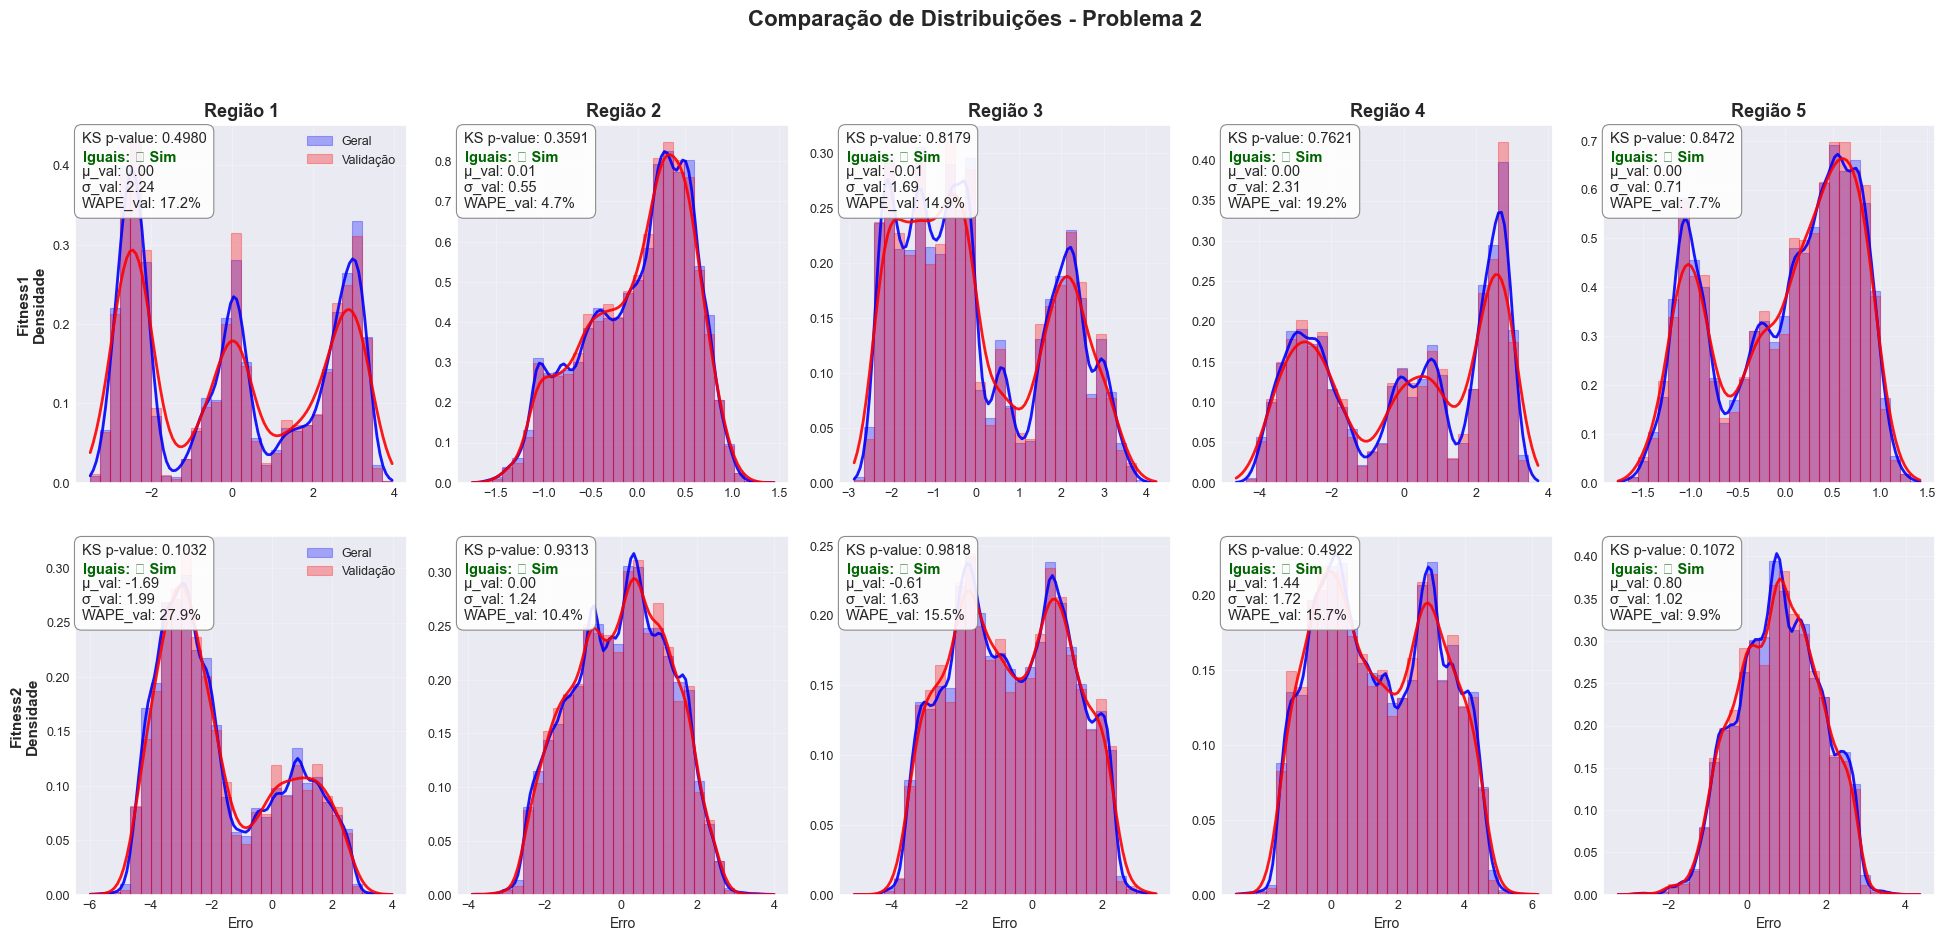

In [5]:
# Visualizar comparações de distribuições - Problema 1
print("Plotando comparações de distribuições - Problema 1...")
plota_comparacao_distribuicoes(df_surrogate1, df_validacao1, df_todos_resultados, problema_num=1)

# Visualizar comparações de distribuições - Problema 2
print("Plotando comparações de distribuições - Problema 2...")
plota_comparacao_distribuicoes(df_surrogate2, df_validacao2, df_todos_resultados, problema_num=2)

# 2. MCMC
**Algoritmo:** Metropolis-Hastings com Kernel Density Estimation (KDE)
- Gera via MCMC amostras das distribuicoes de erros (por problema/regiao)
- Kolmogorov-Smirnov + analise distribuicoes para comparar: amostra gerada mcmc vs. distribuicoes do erro em validacao (3%) e base completa (100%)

In [6]:
df_mcmc1 = gerar_amostras_mcmc_por_problema(
    df_validacao=df_validacao1,
    n_samples=200
)

df_mcmc2 = gerar_amostras_mcmc_por_problema(
    df_validacao=df_validacao2,
    n_samples=200,
)

df_mcmc1.to_parquet('data/df_mcmc1.parquet')
df_mcmc2.to_parquet('data/df_mcmc2.parquet')

print(f"  - df_mcmc1 (Problema 1): {len(df_mcmc1)} amostras")
print(f"  - df_mcmc2 (Problema 2): {len(df_mcmc2)} amostras")
display(df_mcmc1.head())
display(df_mcmc2.head())


🔄 GERANDO AMOSTRAS MCMC PARA PROBLEMA
Colunas: erro1_c1 e erro2_c1
Amostras por região: 200

📊 Gerando amostras para erro1_c1...


Gerando amostras MCMC por região para coluna 'erro1_c1'
Modo adaptativo: Ativado
Proposal scale: 0.7

📍 Região 1:
MCMC completado:
  - Total de iterações: 3,000
  - Burn-in: 1,000
  - Thinning: 10
  - Amostras geradas: 200
  - Taxa de aceitação: 45.90%
  - Proposal std final: 1.5306
  ✅ Taxa de aceitação adequada (15-70%).
  📊 Comparação de estatísticas:
     Original  - Média:  -0.0001, Std:   0.8788
     MCMC      - Média:   0.1706, Std:   0.8892

📍 Região 2:
MCMC completado:
  - Total de iterações: 3,000
  - Burn-in: 1,000
  - Thinning: 10
  - Amostras geradas: 200
  - Taxa de aceitação: 49.60%
  - Proposal std final: 0.9063
  ✅ Taxa de aceitação adequada (15-70%).
  📊 Comparação de estatísticas:
     Original  - Média:   0.0043, Std:   0.4337
     MCMC      - Média:  -0.0088, Std:   0.4710

📍 Região 3:
MCMC completado:
  - Total de iterações: 3,000
  -

,index_linha,regiao,erro1_c1,erro2_c1
0,0,1,-1.313918,-0.484307
1,1,1,0.914130,0.632254
2,2,1,0.154986,0.960702
3,3,1,-0.634165,-0.651020
4,4,1,0.939957,0.703797


,index_linha,regiao,erro1_c1,erro2_c1
0,0,1,0.441198,-3.528011
1,1,1,2.860782,1.527073
2,2,1,2.758490,-0.195303
3,3,1,-0.355703,-3.481056
4,4,1,3.966358,1.404615


Plotando comparações de distribuições - Problema 1...


/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/src/visualization.py:1204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.99], pad=0.5)
/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


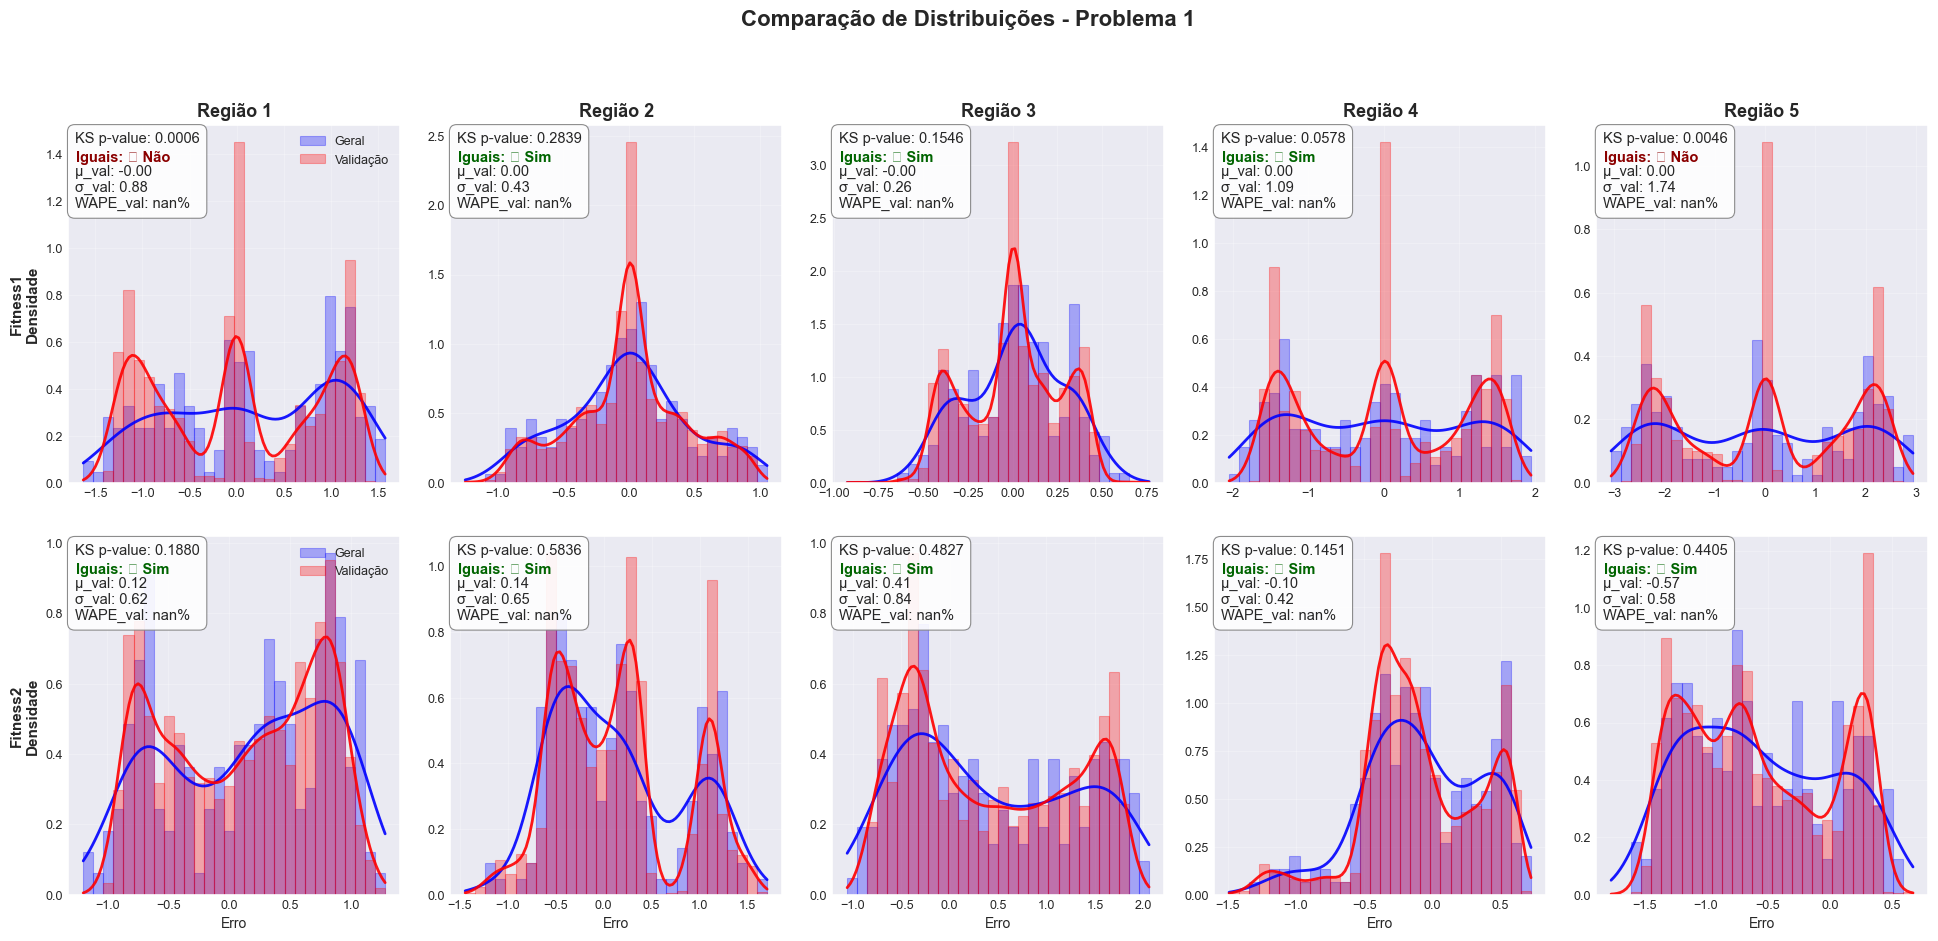

Plotando comparações de distribuições - Problema 2...


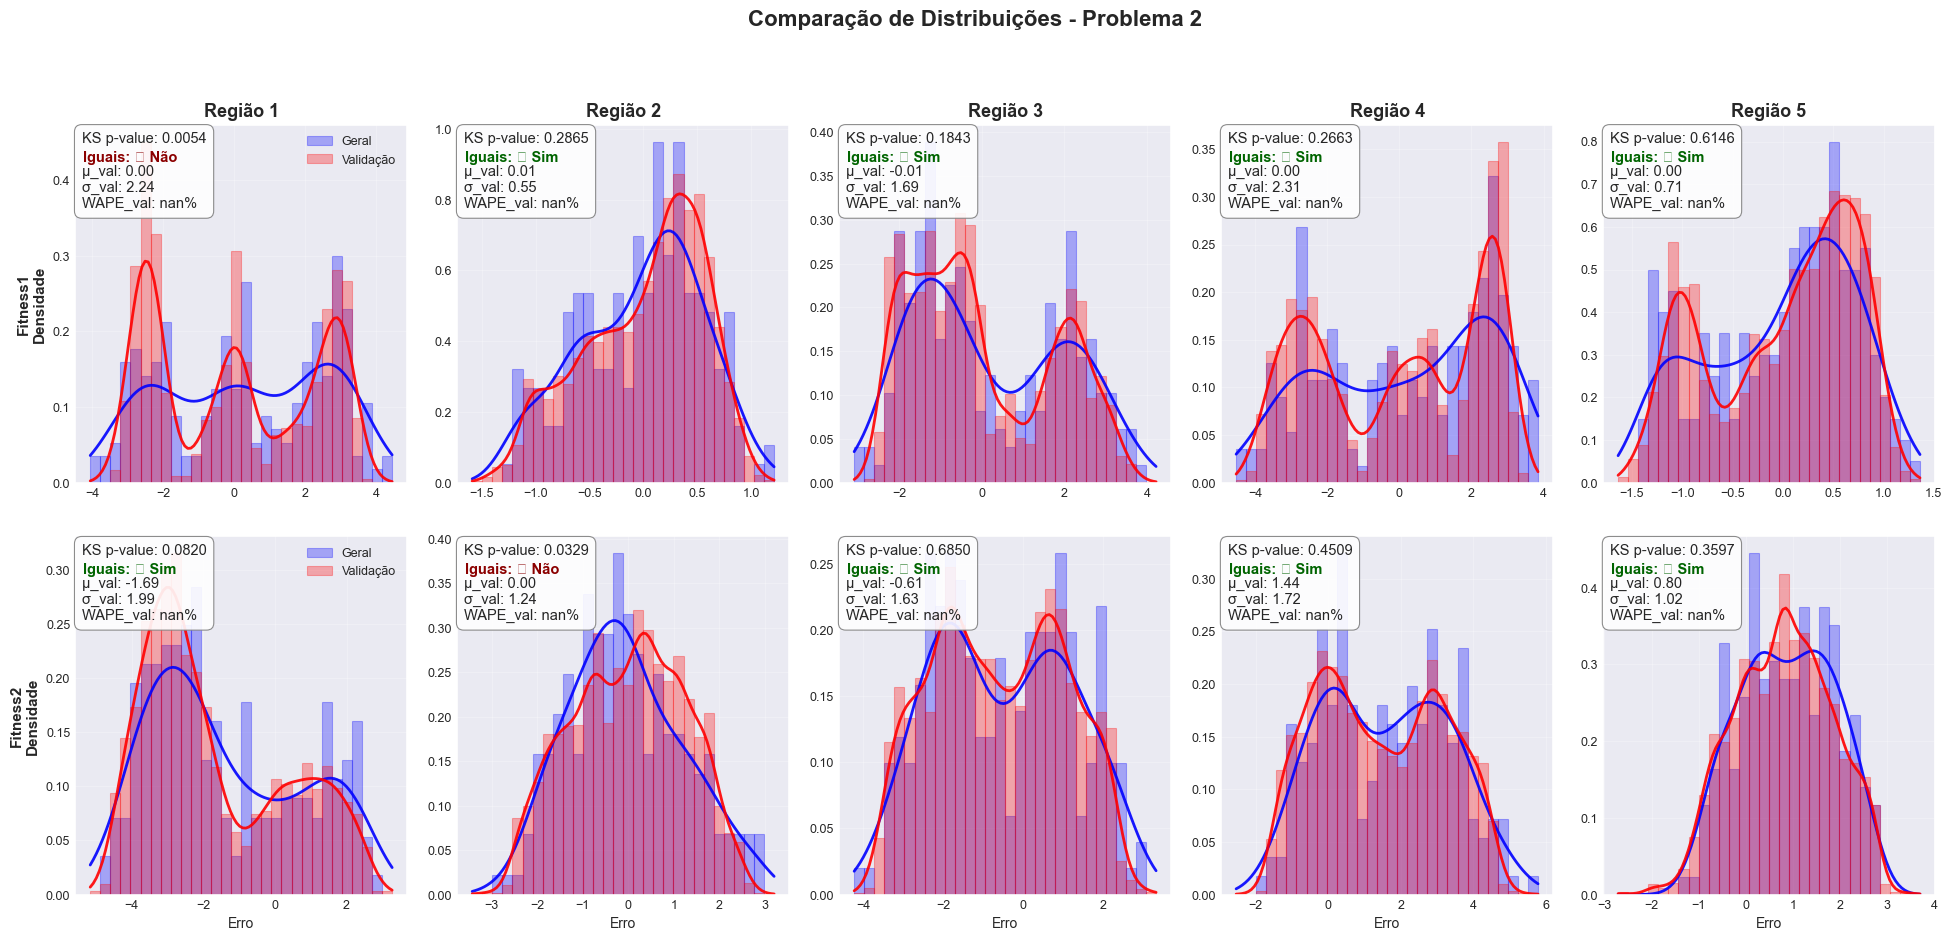

In [7]:
# Problema 1
df_dist1_f1 = comparar_distribuicoes(df_mcmc1, df_validacao1, col='erro1_c1', problema='problema1', calcula_wape=False)
df_dist1_f2 = comparar_distribuicoes(df_mcmc1, df_validacao1, col='erro2_c1', problema='problema1', calcula_wape=False)

# Problema 2
df_dist2_f1 = comparar_distribuicoes(df_mcmc2, df_validacao2, col='erro1_c1', problema='problema2', calcula_wape=False)
df_dist2_f2 = comparar_distribuicoes(df_mcmc2, df_validacao2, col='erro2_c1', problema='problema2', calcula_wape=False)

# Combinar todos os resultados
df_todos_resultados = pd.concat([df_dist1_f1, df_dist1_f2, df_dist2_f1, df_dist2_f2], ignore_index=True)

# Visualizar comparações de distribuições - Problema 1
print("Plotando comparações de distribuições - Problema 1...")
plota_comparacao_distribuicoes(df_mcmc1, df_validacao1, df_todos_resultados, problema_num=1)

# Visualizar comparações de distribuições - Problema 2
print("Plotando comparações de distribuições - Problema 2...")
plota_comparacao_distribuicoes(df_mcmc2, df_validacao2, df_todos_resultados, problema_num=2)

Plotando comparações de distribuições - Problema 1...


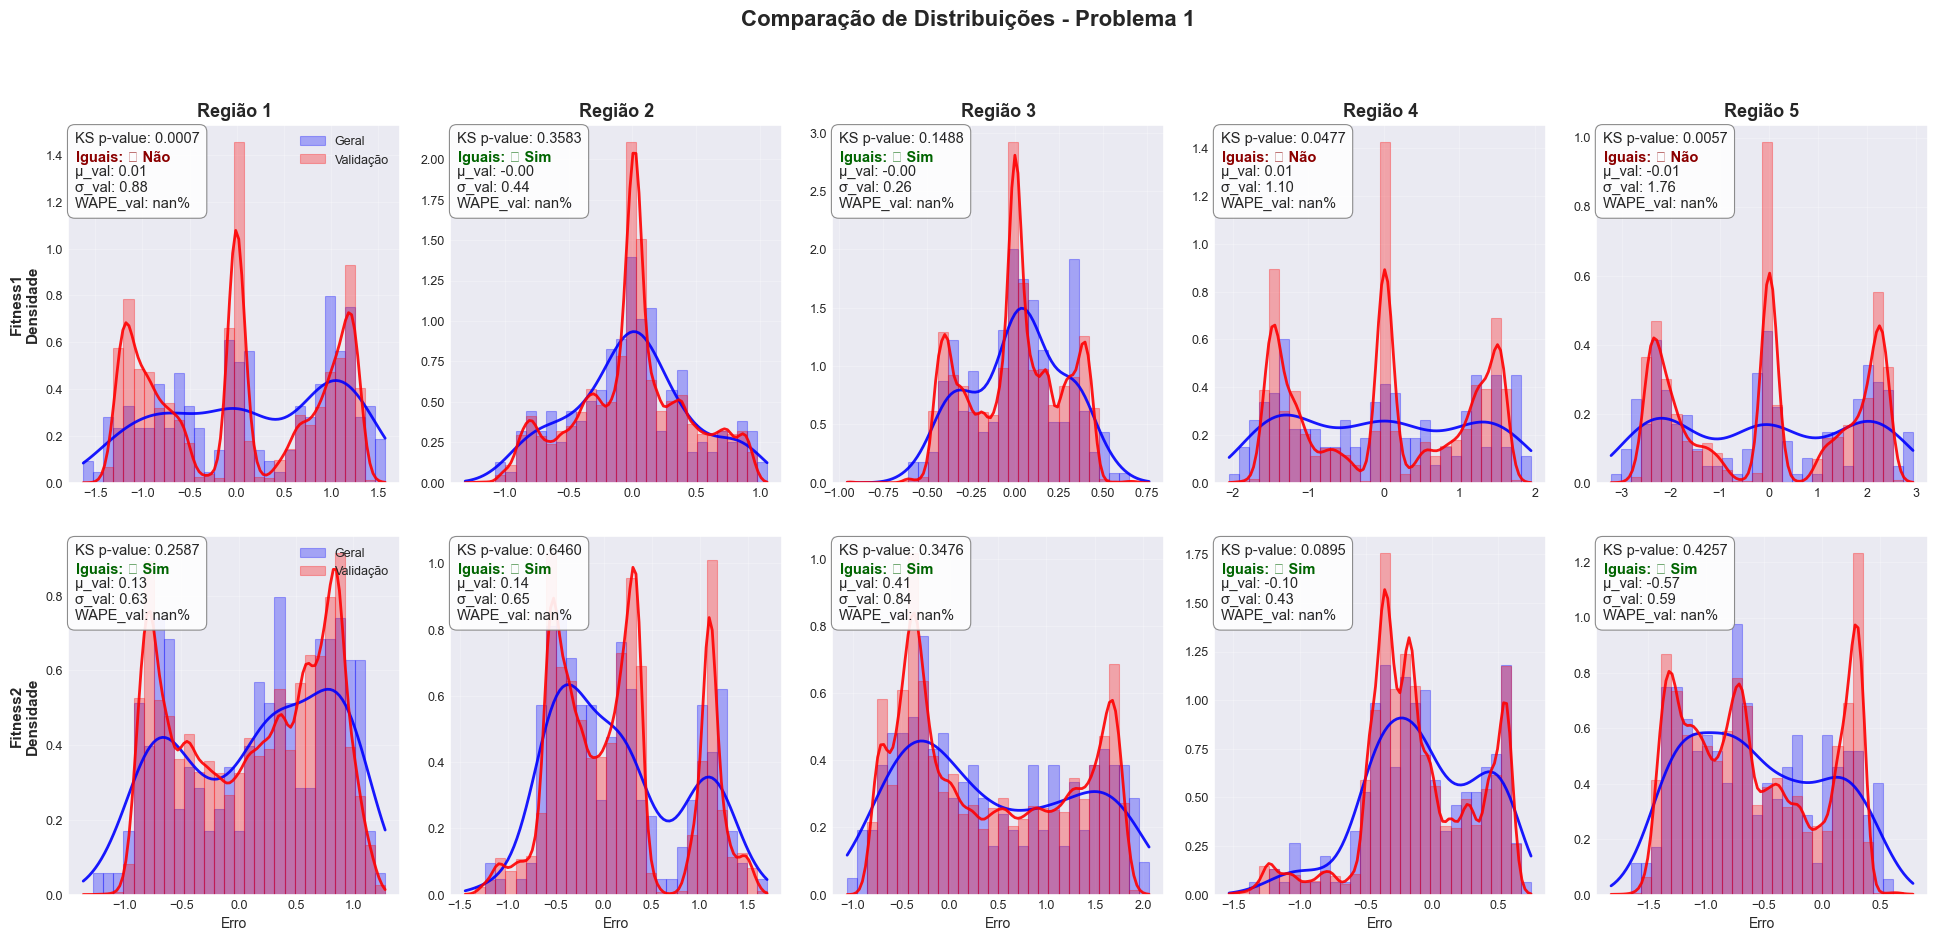

Plotando comparações de distribuições - Problema 2...


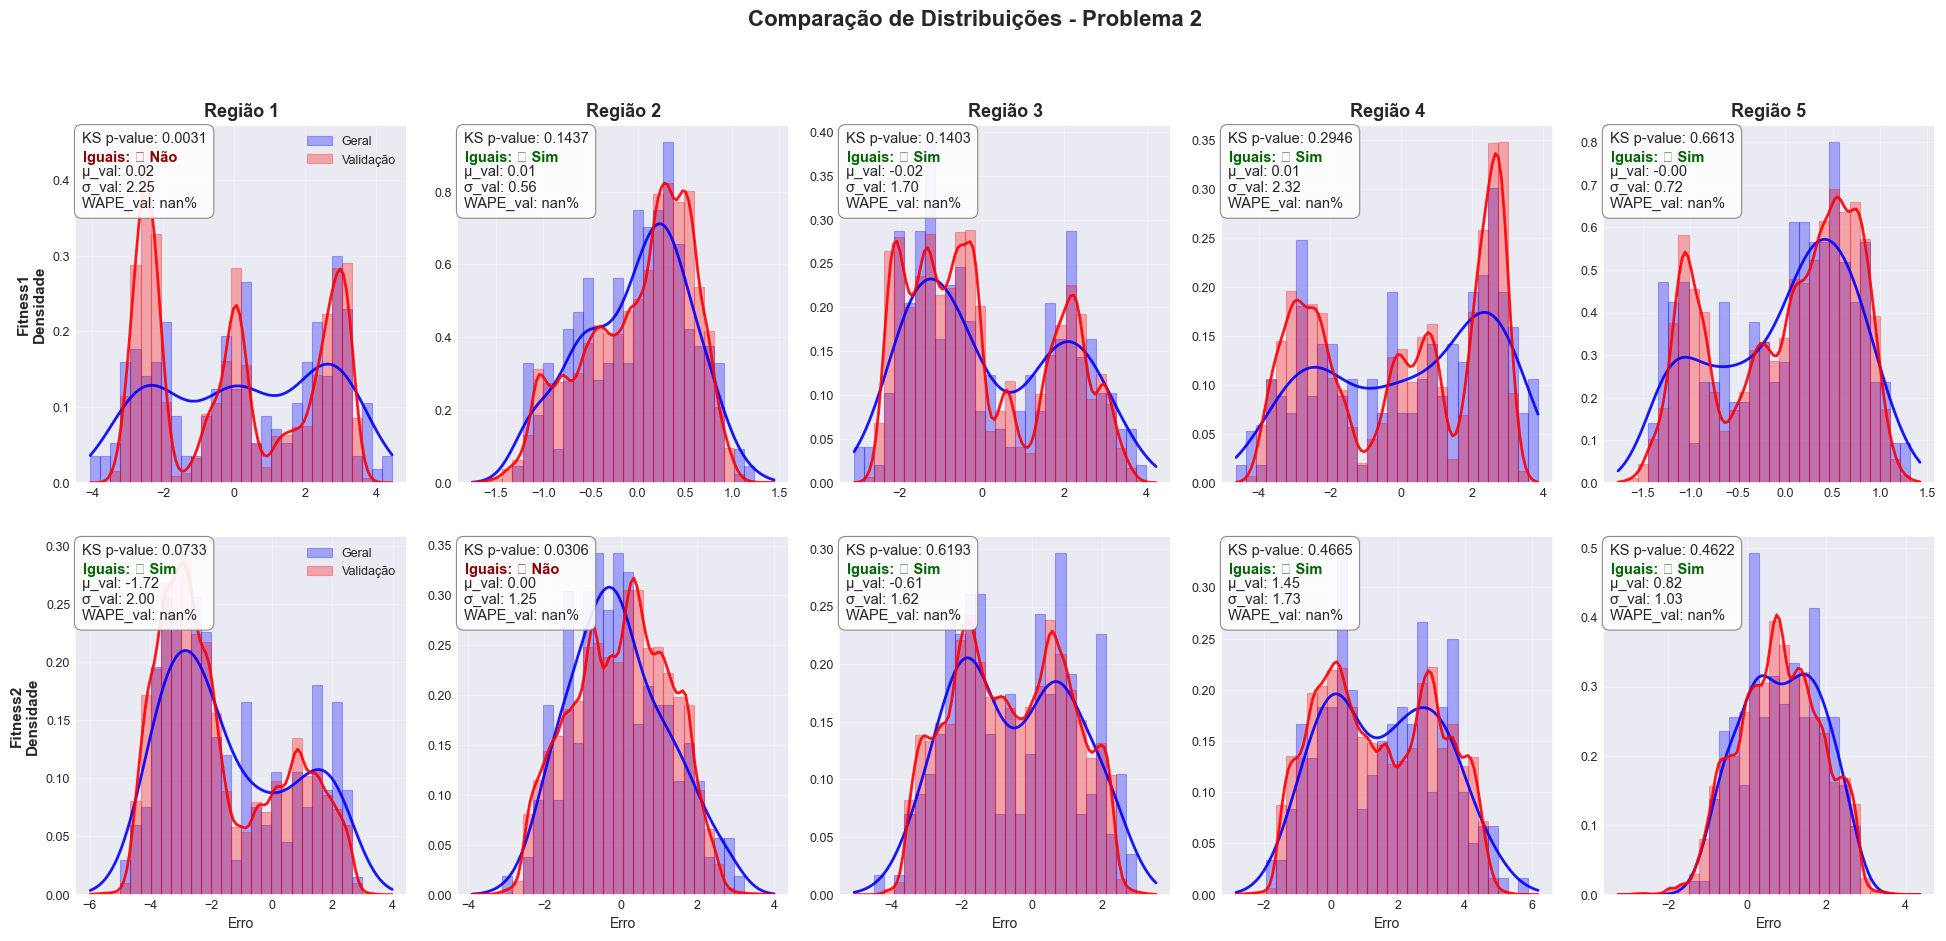

In [8]:
# Problema 1
df_dist1_f1 = comparar_distribuicoes(df_mcmc1, df_surrogate1, col='erro1_c1', problema='problema1', calcula_wape=False)
df_dist1_f2 = comparar_distribuicoes(df_mcmc1, df_surrogate1, col='erro2_c1', problema='problema1', calcula_wape=False)

# Problema 2
df_dist2_f1 = comparar_distribuicoes(df_mcmc2, df_surrogate2, col='erro1_c1', problema='problema2', calcula_wape=False)
df_dist2_f2 = comparar_distribuicoes(df_mcmc2, df_surrogate2, col='erro2_c1', problema='problema2', calcula_wape=False)

# Combinar todos os resultados
df_todos_resultados = pd.concat([df_dist1_f1, df_dist1_f2, df_dist2_f1, df_dist2_f2], ignore_index=True)

# Visualizar comparações de distribuições - Problema 1
print("Plotando comparações de distribuições - Problema 1...")
plota_comparacao_distribuicoes(df_mcmc1, df_surrogate1, df_todos_resultados, problema_num=1)

# Visualizar comparações de distribuições - Problema 2
print("Plotando comparações de distribuições - Problema 2...")
plota_comparacao_distribuicoes(df_mcmc2, df_surrogate2, df_todos_resultados, problema_num=2)